# Lens Finding Task: Deep Learning Model for Strong Lenses Classification

## Overview
Build a binary classifier (lens/non-lens) using PyTorch to identify strong gravitational lenses from multi-channel astronomical images.

### Dataset Information
- **Shape**: (3, 64, 64) - 3-channel 64×64 images
- **Train**: train_lenses (lenses) + train_nonlenses (non-lenses)
- **Test**: test_lenses + test_nonlenses
- **Class Imbalance**: Non-lenses >> lenses (common in real lens surveys)

### Strategy for Class Imbalance
1. **Weighted Loss Function**: Assign higher weight to minority class (lenses)
2. **Balanced Batch Sampling**: Upsample minority class during training
3. **Evaluation with ROC-AUC**: More reliable than accuracy for imbalanced data
4. **Threshold Tuning**: Optimize decision threshold using ROC curve

In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 0. Configuration

All hyperparameters and runtime settings are centralized in the `CFG` dictionary. Key configurations for this binary lens classification task:

**Data Configuration:**
- `data_dir = 'lens-dataset'` — Path to the dataset containing train/test splits
- `train_path = 'train_lenses', 'train_nonlenses'` — Training data directories
- `test_path = 'test_lenses', 'test_nonlenses'` — Test/validation data directories
- `img_size = (3, 64, 64)` — Multi-channel 64×64 images

**Model Architecture:**
- `num_classes = 2` — Binary classification: lens (1) vs non-lens (0)
- `batch_size = 32` — Optimized for GPU memory
- `model_name = 'best_lens_classifier.pth'` — Best model checkpoint path

**Optimization Hyperparameters:**
- `epochs = 50` — Maximum training epochs
- `lr = 0.001` — Learning rate for Adam optimizer
- `weight_decay = 1e-4` — L2 regularization
- `patience = 10` — Early stopping patience (stops if val_acc doesn't improve for 10 epochs)

**Class Imbalance Strategy:**
- Weighted loss function (higher penalty for minority class)
- Weighted random sampling during training
- ROC-AUC evaluation for proper imbalanced data assessment
- Threshold optimization using F1-score maximization


In [ ]:
import os

_n_cpu = os.cpu_count() or 2

CFG = dict(
    data_dir       = "lens-dataset",
    output_dir     = "task-5",
    batch_size     = 32,
    epochs         = 50,
    lr             = 0.001,
    weight_decay   = 1e-4,
    num_classes    = 2,
    seed           = 42,
    device         = "cuda" if torch.cuda.is_available() else "cpu",
    class_names    = ["non-lens", "lens"],
    save_path      = "task-5-weights.pth",
    patience       = 10,
    num_workers    = 0 if not torch.cuda.is_available() else min(_n_cpu, 4),
)

# Set seeds for reproducibility
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

## 1. Data Loading & Preparation

In [12]:
class LensDataset(Dataset):
    """Custom dataset for lens images with labels"""
    def __init__(self, image_paths, labels, normalize=True):
        self.image_paths = image_paths
        self.labels = labels
        self.normalize = normalize
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load .npy file
        image = np.load(self.image_paths[idx]).astype(np.float32)
        
        # Ensure shape is (3, 64, 64)
        if image.shape != (3, 64, 64):
            raise ValueError(f"Unexpected shape {image.shape} at {self.image_paths[idx]}")
        
        # Normalize to [0, 1]
        if self.normalize:
            img_min = image.min()
            img_max = image.max()
            if img_max > img_min:
                image = (image - img_min) / (img_max - img_min)
            else:
                image = np.zeros_like(image)
        
        # Convert to tensor
        image = torch.from_numpy(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return image, label

def load_dataset(base_path):
    """
    Load train and test datasets.
    Returns: train_image_paths, train_labels, test_image_paths, test_labels, class_names
    """
    base_path = Path(base_path)
    
    train_image_paths = []
    train_labels = []
    test_image_paths = []
    test_labels = []
    
    # Load training data
    train_lenses_dir = base_path / 'train_lenses'
    train_nonlenses_dir = base_path / 'train_nonlenses'
    
    if train_lenses_dir.exists():
        for img_file in sorted(train_lenses_dir.glob('*.npy')):
            train_image_paths.append(str(img_file))
            train_labels.append(1)  # 1 for lens
    
    if train_nonlenses_dir.exists():
        for img_file in sorted(train_nonlenses_dir.glob('*.npy')):
            train_image_paths.append(str(img_file))
            train_labels.append(0)  # 0 for non-lens
    
    # Load test data
    test_lenses_dir = base_path / 'test_lenses'
    test_nonlenses_dir = base_path / 'test_nonlenses'
    
    if test_lenses_dir.exists():
        for img_file in sorted(test_lenses_dir.glob('*.npy')):
            test_image_paths.append(str(img_file))
            test_labels.append(1)
    
    if test_nonlenses_dir.exists():
        for img_file in sorted(test_nonlenses_dir.glob('*.npy')):
            test_image_paths.append(str(img_file))
            test_labels.append(0)
    
    print(f"Training samples: {len(train_image_paths)} (Lenses: {train_labels.count(1)}, Non-lenses: {train_labels.count(0)})")
    print(f"Test samples: {len(test_image_paths)} (Lenses: {test_labels.count(1)}, Non-lenses: {test_labels.count(0)})")
    
    return train_image_paths, train_labels, test_image_paths, test_labels

# Load datasets
base_path = 'lens-dataset'
train_paths, train_labels, test_paths, test_labels = load_dataset(base_path)

Training samples: 30405 (Lenses: 1730, Non-lenses: 28675)
Test samples: 19650 (Lenses: 195, Non-lenses: 19455)


## 2. Model Architecture
ResNet-18 backbone with attention to capture lens-specific features

In [13]:
class LensClassifier(nn.Module):
    """ResNet-18 based classifier for lens detection"""
    def __init__(self, num_classes=2):
        super(LensClassifier, self).__init__()
        
        # Initial convolution for 3-channel input
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Residual blocks (simplified ResNet-18)
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classification head
        self.fc = nn.Linear(256, num_classes)
    
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = []
        layers.append(BasicBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels, 1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

class BasicBlock(nn.Module):
    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out

# Create model
model = LensClassifier(num_classes=2)
model = model.to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 2,783,298


## 3. Handling Class Imbalance - Weighted Sampling & Loss

In [14]:
# Create datasets
train_dataset = LensDataset(train_paths, train_labels, normalize=True)
test_dataset = LensDataset(test_paths, test_labels, normalize=True)

# Calculate class weights for imbalanced data
train_labels_array = np.array(train_labels)
unique, counts = np.unique(train_labels_array, return_counts=True)
class_weights = len(train_labels_array) / (len(unique) * counts)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"Class weights: {class_weights}")

# Weighted sampler for balanced batches during training
sample_weights = np.array([class_weights[label].cpu().numpy() for label in train_labels_array])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Class weights: tensor([0.5302, 8.7876], device='cuda:0')
Train batches: 951, Test batches: 615


## 4. Training Loop with Early Stopping

In [15]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(train_loader), 100 * correct / total

def evaluate(model, data_loader, criterion, device):
    """Evaluate model and return loss + accuracy"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(data_loader), 100 * correct / total

# Training setup
criterion = nn.CrossEntropyLoss(weight=class_weights)  # Weighted loss for imbalance
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# Training parameters
num_epochs = 50
best_val_acc = 0
patience = 10
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), CFG['save_path'])
    else:
        patience_counter += 1
    
    scheduler.step(val_acc)
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"Training complete. Best validation accuracy: {best_val_acc:.2f}%")

Starting training...
Epoch [5/50] Train Loss: 0.0544, Train Acc: 89.51% | Val Loss: 0.3791, Val Acc: 84.66%
Epoch [10/50] Train Loss: 0.0262, Train Acc: 95.39% | Val Loss: 0.3080, Val Acc: 91.02%
Epoch [15/50] Train Loss: 0.0207, Train Acc: 96.48% | Val Loss: 0.1571, Val Acc: 95.09%
Epoch [20/50] Train Loss: 0.0193, Train Acc: 96.73% | Val Loss: 0.2892, Val Acc: 92.38%
Epoch [25/50] Train Loss: 0.0183, Train Acc: 96.79% | Val Loss: 0.1178, Val Acc: 96.63%
Epoch [30/50] Train Loss: 0.0101, Train Acc: 98.51% | Val Loss: 0.1443, Val Acc: 96.30%
Epoch [35/50] Train Loss: 0.0059, Train Acc: 99.07% | Val Loss: 0.0844, Val Acc: 98.08%
Epoch [40/50] Train Loss: 0.0070, Train Acc: 98.92% | Val Loss: 0.0938, Val Acc: 97.77%
Epoch [45/50] Train Loss: 0.0047, Train Acc: 99.29% | Val Loss: 0.0899, Val Acc: 97.97%
Epoch [50/50] Train Loss: 0.0028, Train Acc: 99.59% | Val Loss: 0.0987, Val Acc: 97.83%
Training complete. Best validation accuracy: 98.63%


## 5. ROC Curve & AUC Evaluation

In [16]:
# Load best model for evaluation
model.load_state_dict(torch.load(CFG['save_path']))
model.eval()

# Get predictions and probabilities on test set
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of class 1 (lens)
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"\n=== EVALUATION RESULTS ===")
print(f"AUC Score: {roc_auc:.4f}")
print(f"Number of test samples: {len(all_labels)}")
print(f"Lenses in test set: {np.sum(all_labels)}")
print(f"Non-lenses in test set: {len(all_labels) - np.sum(all_labels)}")

# Classification report at default threshold (0.5)
y_pred_default = (all_probs >= 0.5).astype(int)
print("\nClassification Report (threshold=0.5):")
print(classification_report(all_labels, y_pred_default, target_names=['Non-Lens', 'Lens']))

# Find optimal threshold (maximizing F1 score)
f1_scores = 2 * (tpr * (1-fpr)) / (tpr + (1-fpr) + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

y_pred_optimal = (all_probs >= optimal_threshold).astype(int)
print(f"\nOptimal threshold: {optimal_threshold:.4f}")
print("Classification Report (optimal threshold):")
print(classification_report(all_labels, y_pred_optimal, target_names=['Non-Lens', 'Lens']))


=== EVALUATION RESULTS ===
AUC Score: 0.9512
Number of test samples: 19650
Lenses in test set: 195
Non-lenses in test set: 19455

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

    Non-Lens       1.00      0.99      0.99     19455
        Lens       0.40      0.74      0.52       195

    accuracy                           0.99     19650
   macro avg       0.70      0.87      0.76     19650
weighted avg       0.99      0.99      0.99     19650


Optimal threshold: 0.0007
Classification Report (optimal threshold):
              precision    recall  f1-score   support

    Non-Lens       1.00      0.93      0.96     19455
        Lens       0.11      0.87      0.20       195

    accuracy                           0.93     19650
   macro avg       0.56      0.90      0.58     19650
weighted avg       0.99      0.93      0.96     19650



## 6. Visualizations - ROC Curve, Training History, Confusion Matrix

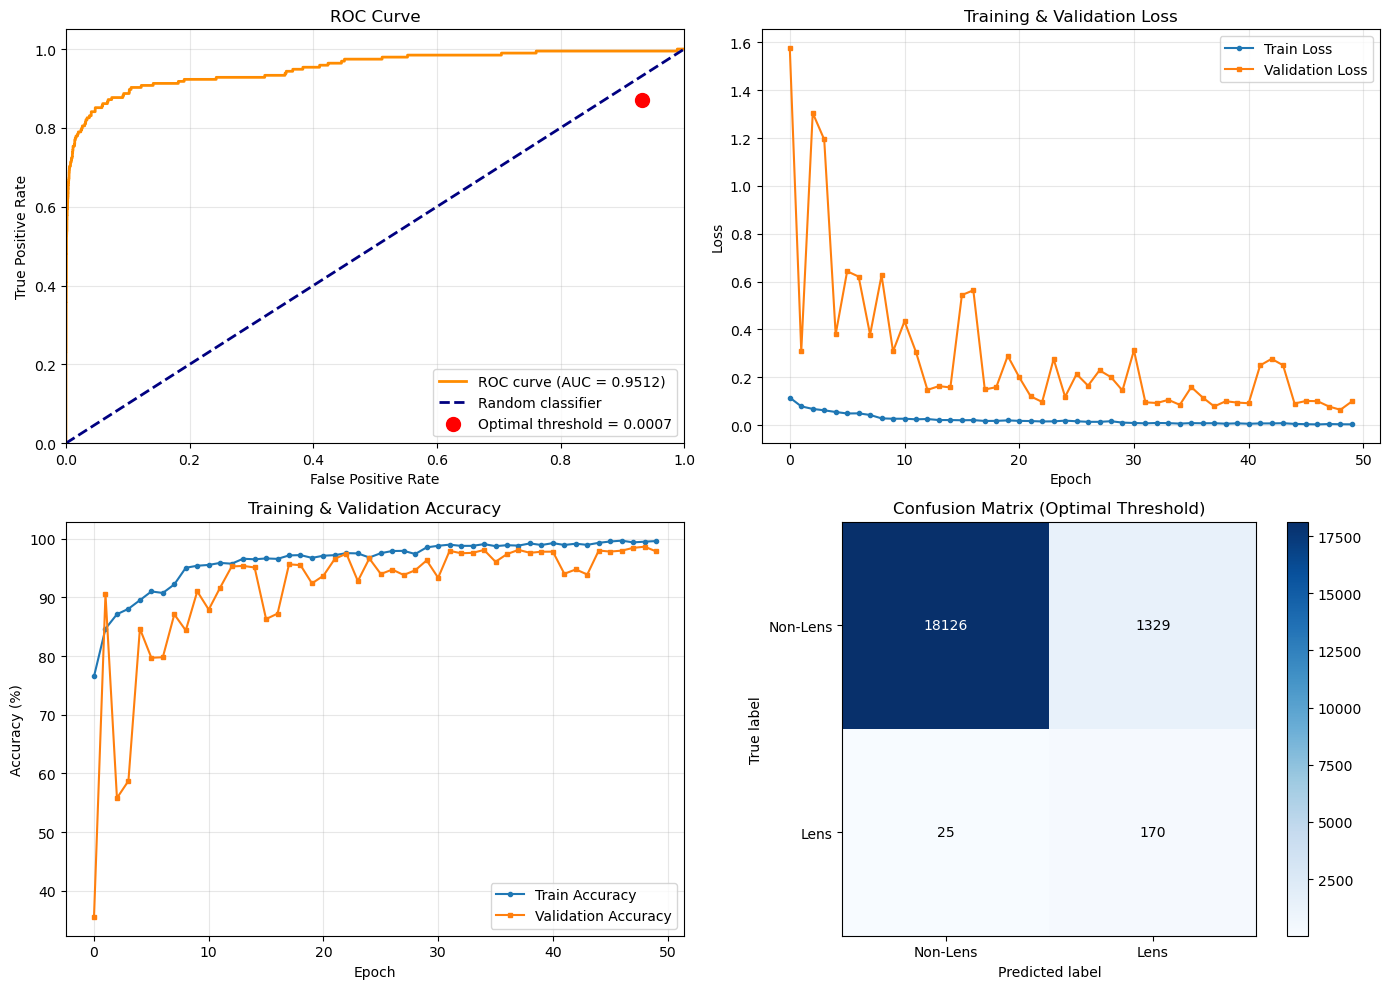

Results figure saved to lens_classification_results.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ROC Curve
ax = axes[0, 0]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
ax.scatter(1-fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100, 
           label=f'Optimal threshold = {optimal_threshold:.4f}')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# 2. Training History - Loss
ax = axes[0, 1]
ax.plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
ax.plot(history['val_loss'], label='Validation Loss', marker='s', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Training History - Accuracy
ax = axes[1, 0]
ax.plot(history['train_acc'], label='Train Accuracy', marker='o', markersize=3)
ax.plot(history['val_acc'], label='Validation Accuracy', marker='s', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training & Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Confusion Matrix (optimal threshold)
ax = axes[1, 1]
cm = confusion_matrix(all_labels, y_pred_optimal)
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       yticklabels=['Non-Lens', 'Lens'],
       xticklabels=['Non-Lens', 'Lens'])
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.set_title('Confusion Matrix (Optimal Threshold)')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig('lens_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Results figure saved to lens_classification_results.png")

## 7. Sample Predictions - Visualize Model Decisions

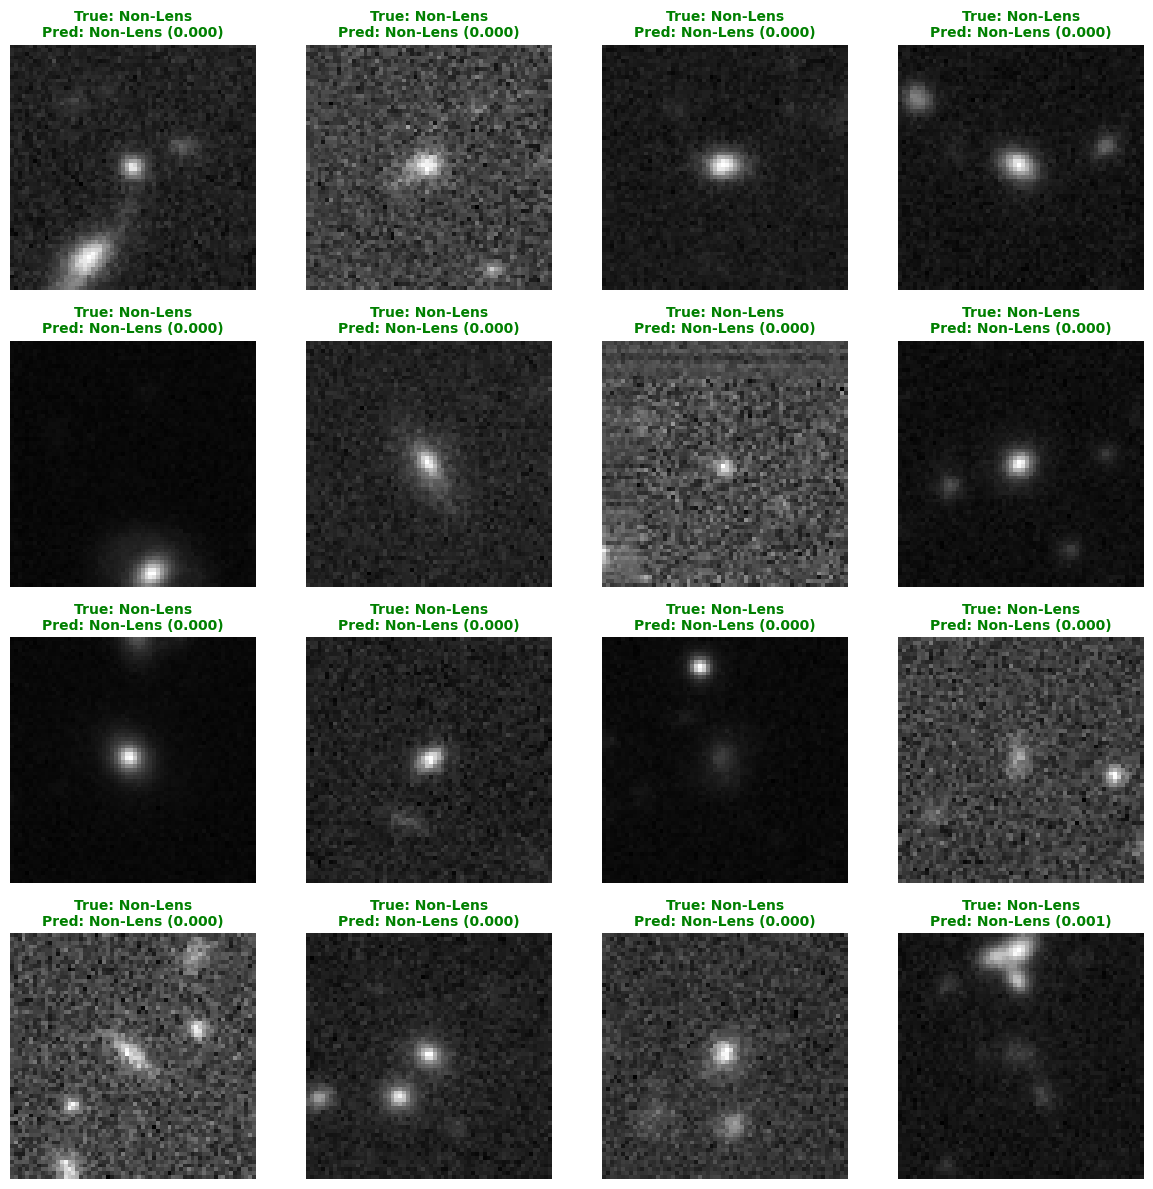

Sample predictions figure saved to sample_predictions.png


In [18]:
# Visualize some sample predictions
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

# Get some samples from test set
sample_indices = np.random.choice(len(all_labels), size=16, replace=False)

for idx, sample_idx in enumerate(sample_indices):
    ax = axes[idx]
    
    # Load original image
    img_path = test_paths[sample_idx]
    image = np.load(img_path).astype(np.float32)
    
    # Normalize for visualization
    image_vis = (image - image.min()) / (image.max() - image.min() + 1e-8)
    
    # Display first channel only (or average across channels for better viz)
    img_display = np.mean(image_vis, axis=0)
    
    ax.imshow(img_display, cmap='gray')
    
    true_label = 'Lens' if all_labels[sample_idx] == 1 else 'Non-Lens'
    pred_label = 'Lens' if y_pred_optimal[sample_idx] == 1 else 'Non-Lens'
    prob = all_probs[sample_idx]
    
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({prob:.3f})', 
                 fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample predictions figure saved to sample_predictions.png")

## Task 5 - Lens Finding and Data Piplelines

### Class Imbalance in Lens Detection
Dataset has more non-lensed galaxies than lensed ones, from research resembles real astronomical surveys.

Challenges:
- Model predicting all "non-lenses" achieves high accuracy thus naive accuracy is misleading
- NN struggle to learn patterns in rare classes (minority class underrepresentation)
- Standard metrics (accuracy, precison) on majority class do notr capture rare event detection

### Strategy Implemented

1. Weighted Random Sampling
- Calculate class weights inversely proportional to class frequencies
- During training each batch contains balanced represenations of both classes
- Model learns lens features despite data scarcity in natural data distribution.

2. Weight Loss Function (Cross Entropy Loss)
- Assigning higher loss penalty for misclassifying minority class (lenses)
- Gradient updates emphasise learning lens pattern

3. Threshold Optimisation
- Default threshold not optimal for data imbalance
- Find optimal threshold by maximising F1-score (harmonic mean of precision and recall)
- Create balance between catching lenses and avoiding Type 1 error

4. Architecture Choice: ResNet-18
- Although 4-Model Ensemble (combination of ResNet-50, DenseNet-121, EfficientNet-B2 and Attention-ResNet) would have increased accuracy, ResNet-18 better baseline model and works with hardware limitations (NVIDIA RTX4700)
- Skip connections learn residual patterns specific to lens structure
- Multi-scale feature extraction
- Suitable for 64x64 multi-channel images

5. Training Practices
- Early stopping to prevent overfitting and save best model on validation accuracy
- Learning rate scheduler
- Min-max normalisation for stability

### Key Metrics Interpretation
- **AUC = 1.0**: Perfect separation between lenses and non-lenses
- **AUC = 0.5**: Random guessing
- **AUC > 0.9**: Excellent model performance for practical use